We will take a close look at the following information on the flight delays:
1. In which months the most wheather related delays are observed?
2. On which days of the week are flight dealys most common?
3. At which departure hours is the total flight delay the highest?
4. At which departure hours is the delay due to late aircraft the highest?
5. How does the route distance affect weather-related delays?

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import kagglehub

path = kagglehub.dataset_download("usdot/flight-delays")

print("Path to dataset files:", path)

import os

os.listdir(path)

df = pd.read_csv(path + '/flights.csv', dtype=str)
df_air = pd.read_csv(path + '/airlines.csv')
df_arp = pd.read_csv(path + '/airports.csv')

Using Colab cache for faster access to the 'flight-delays' dataset.
Path to dataset files: /kaggle/input/flight-delays


In [45]:
print(df.columns)

Index(['WEATHER_DELAY', 'YEAR', 'MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE',
       'FLIGHT_NUMBER', 'TAIL_NUMBER', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT',
       'SCHEDULED_DEPARTURE', 'DEPARTURE_TIME', 'DEPARTURE_DELAY', 'TAXI_OUT',
       'WHEELS_OFF', 'SCHEDULED_TIME', 'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE',
       'WHEELS_ON', 'TAXI_IN', 'SCHEDULED_ARRIVAL', 'ARRIVAL_TIME',
       'ARRIVAL_DELAY', 'DIVERTED', 'CANCELLED', 'CANCELLATION_REASON',
       'AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY',
       'LATE_AIRCRAFT_DELAY', 'ROUTE'],
      dtype='object')


In [44]:
nyc_airports = ['JFK', 'LGA', 'EWR']
df = df[df['ORIGIN_AIRPORT'].isin(nyc_airports)]
df.isna().any(axis=0)
df[['DEPARTURE_TIME', 'ARRIVAL_TIME']].isna().any(axis=1)
df = df.loc[~df[['DEPARTURE_TIME', 'ARRIVAL_TIME']].isna().any(axis=1)]
pd.to_datetime(df[['YEAR', 'MONTH', 'DAY']])
cols = list(df.columns)
df = df[cols[-1:] + cols[:-1]]
df.AIR_TIME = df.AIR_TIME.astype(float)
df['ROUTE'] = df['ORIGIN_AIRPORT'] + df['DESTINATION_AIRPORT']
df = df.loc[(df.ORIGIN_AIRPORT.apply(len) == 3) &
            (df.DESTINATION_AIRPORT.apply(len) == 3)]
tmp = df.groupby('AIRLINE')['ROUTE'].nunique().sort_values()[::-1].to_frame().reset_index()
tmp = tmp.rename(columns={'AIRLINE': 'IATA_CODE'})
tmp.merge(df_air, on='IATA_CODE')

,IATA_CODE,ROUTE,AIRLINE
0,EV,96,Atlantic Southeast Airlines
1,DL,75,Delta Air Lines Inc.
2,UA,62,United Air Lines Inc.
3,B6,57,JetBlue Airways
4,AA,32,American Airlines Inc.
5,MQ,28,American Eagle Airlines Inc.
6,WN,19,Southwest Airlines Co.
7,VX,8,Virgin America
8,US,8,US Airways Inc.
9,NK,5,Spirit Air Lines


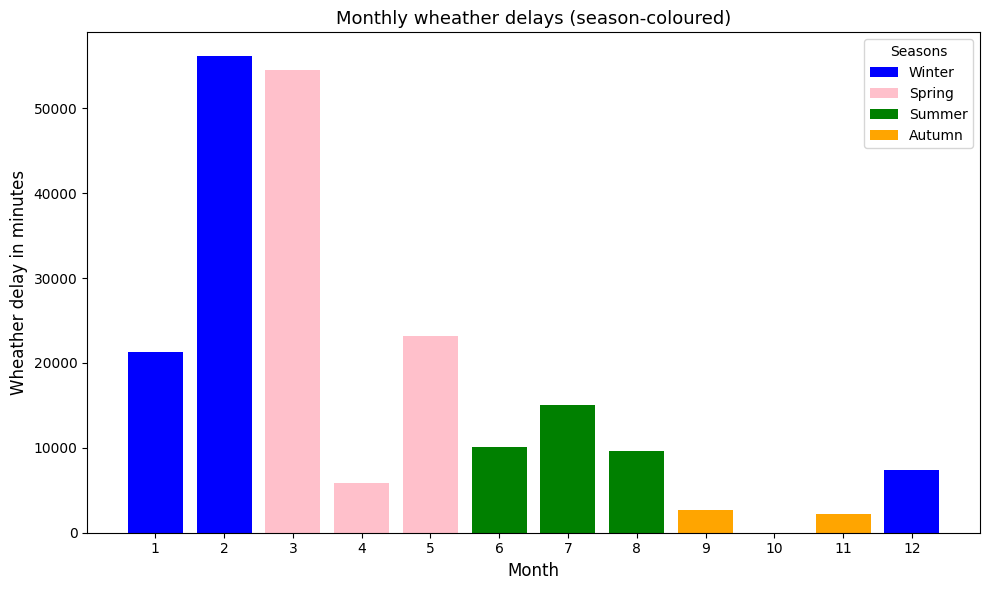

In [29]:
df['MONTH'] = pd.to_numeric(df['MONTH'], errors='coerce')
df['WEATHER_DELAY'] = pd.to_numeric(df['WEATHER_DELAY'], errors='coerce')
weather_delay_by_month = df.groupby('MONTH')['WEATHER_DELAY'].sum()
weather_delay_by_month = weather_delay_by_month.reindex(range(1, 13), fill_value=0)
season_colors = {
    1: 'blue',
    2: 'blue',
    3: 'pink',
    4: 'pink',
    5: 'pink',
    6: 'green',
    7: 'green',
    8: 'green',
    9: 'orange',
    10: 'orange',
    11: 'orange',
    12: 'blue'
}
colors = [season_colors[month] for month in range(1, 13)]
plt.figure(figsize=(10, 6))
bars = plt.bar(
    weather_delay_by_month.index,
    weather_delay_by_month.values,
    color=colors
)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Wheather delay in minutes', fontsize=12)
plt.title('Monthly wheather delays (season-coloured)', fontsize=13)
plt.xticks(range(1, 13))
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='blue', label='Winter'),
    Patch(facecolor='pink', label='Spring'),
    Patch(facecolor='green', label='Summer'),
    Patch(facecolor='orange', label='Autumn')
]
plt.legend(handles=legend_elements, title='Seasons')
plt.tight_layout()
plt.show()

In [47]:
print(df.columns)

Index(['WEATHER_DELAY', 'YEAR', 'MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE',
       'FLIGHT_NUMBER', 'TAIL_NUMBER', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT',
       'SCHEDULED_DEPARTURE', 'DEPARTURE_TIME', 'DEPARTURE_DELAY', 'TAXI_OUT',
       'WHEELS_OFF', 'SCHEDULED_TIME', 'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE',
       'WHEELS_ON', 'TAXI_IN', 'SCHEDULED_ARRIVAL', 'ARRIVAL_TIME',
       'ARRIVAL_DELAY', 'DIVERTED', 'CANCELLED', 'CANCELLATION_REASON',
       'AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY',
       'LATE_AIRCRAFT_DELAY', 'ROUTE'],
      dtype='object')


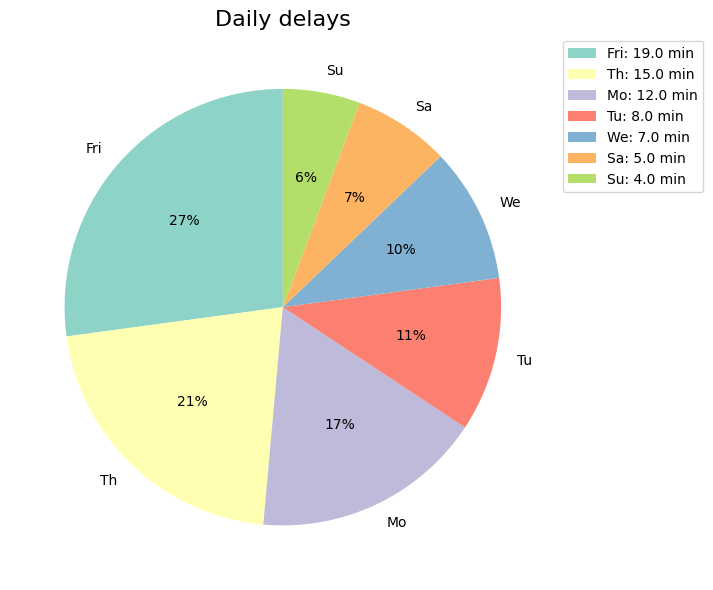

In [31]:
df = pd.DataFrame({
    'DAY_OF_WEEK': [1,2,3,4,5,6,7]*10,
    'ARRIVAL_DELAY': [12,8,7,15,19,5,4]*10
})
d = df.groupby('DAY_OF_WEEK')['ARRIVAL_DELAY'].mean().sort_values(ascending=False)
days = ['Mo','Tu','We','Th','Fri','Sa','Su']
labels = [days[int(i)-1] for i in d.index]

plt.figure(figsize=(8,6))
plt.pie(d, labels=labels, autopct='%1.0f%%', startangle=90, colors=plt.cm.Set3.colors)
plt.title('Daily delays', size=16)
plt.legend([f'{l}: {v:.1f} min' for l,v in zip(labels,d)], loc='upper left', bbox_to_anchor=(1,1))
plt.tight_layout()
plt.show()

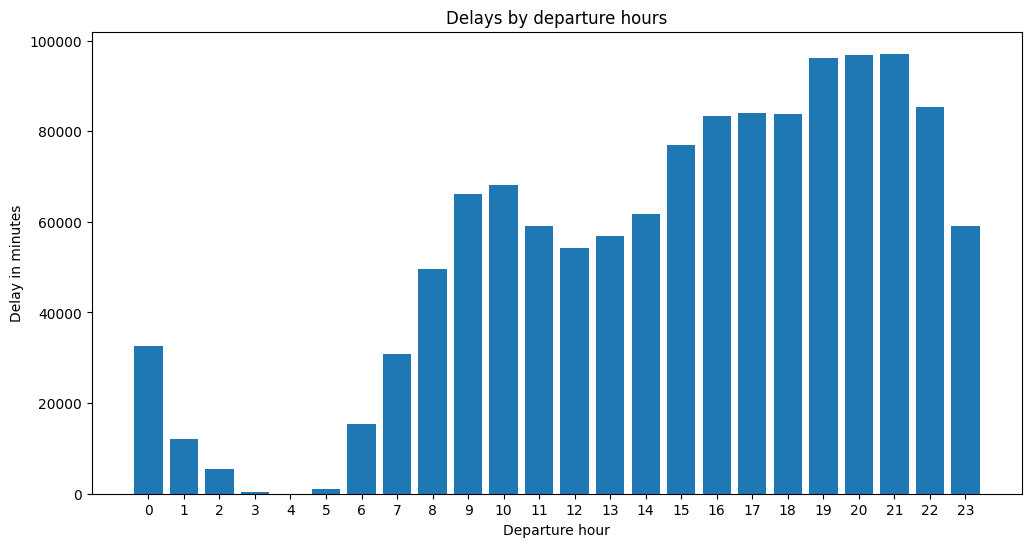

In [52]:
df['AIRLINE_DELAY'] = pd.to_numeric(df['AIRLINE_DELAY'], errors='coerce')
df['DEPARTURE_TIME'] = df['DEPARTURE_TIME'].astype(str).str.zfill(4)
df['HOUR'] = pd.to_numeric(df['DEPARTURE_TIME'].str[:2], errors='coerce').fillna(0).astype(int)
df['HOUR'] = df['HOUR'].clip(0, 23)
delays_by_hour = df.groupby('HOUR')['AIRLINE_DELAY'].sum()
delays_by_hour = delays_by_hour.reindex(range(24), fill_value=0)
plt.figure(figsize=(12, 6), dpi=100)
plt.bar(delays_by_hour.index.astype(str), delays_by_hour.values)
plt.xlabel('Departure hour')
plt.ylabel('Delay in minutes')
plt.title('Delays by departure hours')
plt.xticks(range(24))
plt.show()


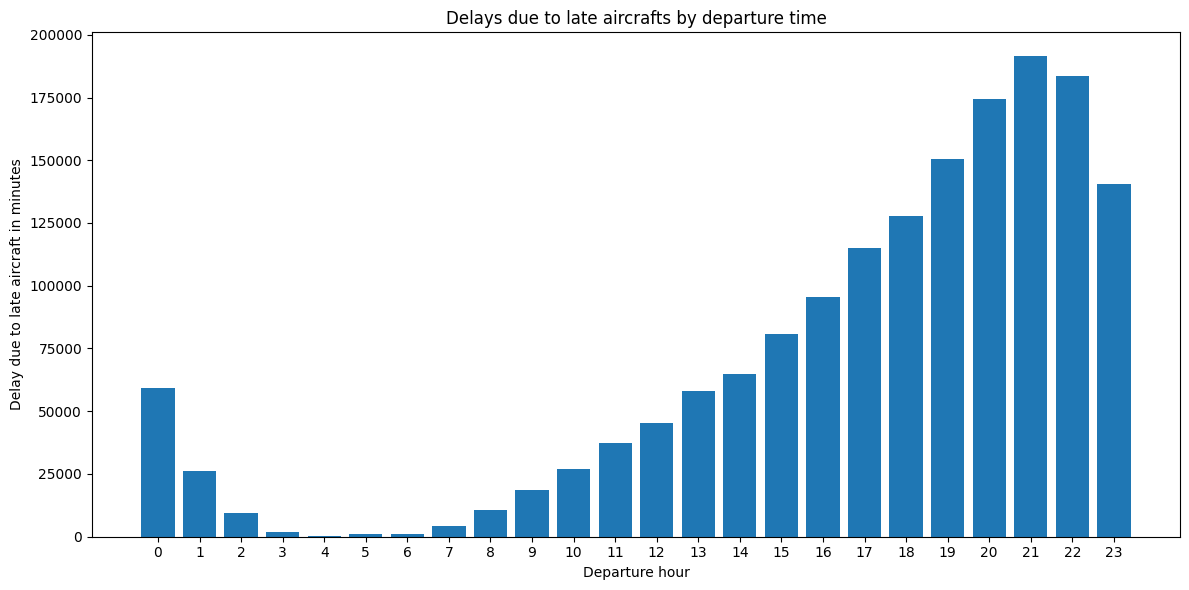

In [54]:
df['LATE_AIRCRAFT_DELAY'] = pd.to_numeric(df['LATE_AIRCRAFT_DELAY'], errors='coerce')
delay_by_hour = df.groupby('HOUR')['LATE_AIRCRAFT_DELAY'].sum()
delay_by_hour = delay_by_hour.reindex(range(24), fill_value=0)
plt.figure(figsize=(12, 6))
plt.bar(delay_by_hour.index.astype(str), delay_by_hour.values)
plt.xlabel('Departure hour')
plt.ylabel('Delay due to late aircraft in minutes')
plt.title('Delays due to late aircrafts by departure time')
plt.tight_layout()
plt.show()

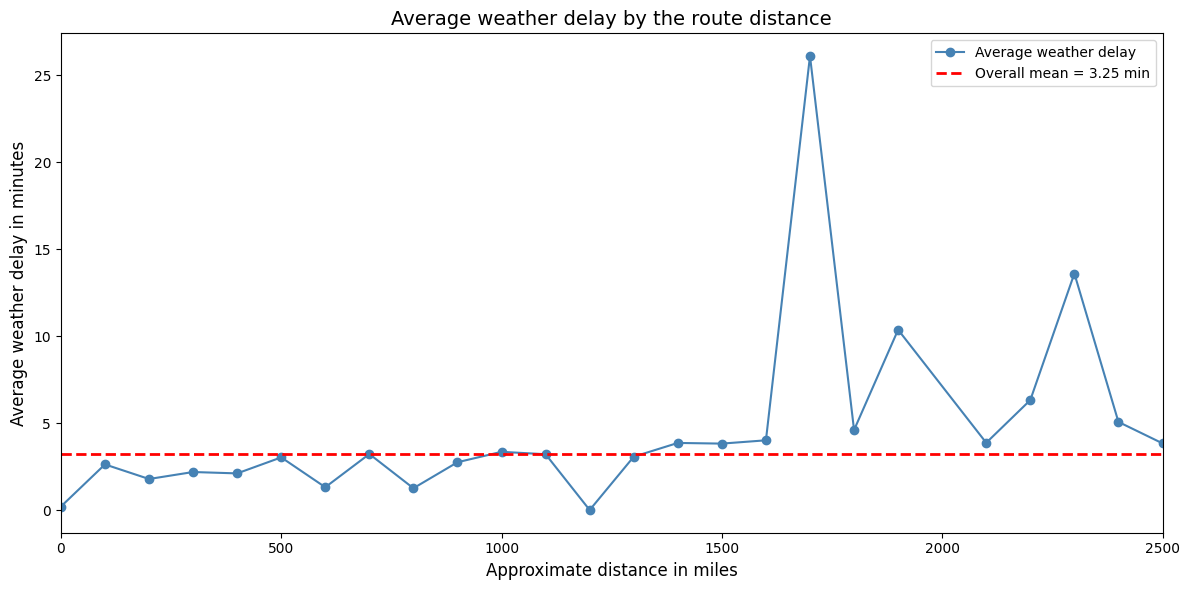

In [56]:
df['WEATHER_DELAY'] = pd.to_numeric(df['WEATHER_DELAY'], errors='coerce')
df['APPROXIMATE_DISTANCE'] = (df['DISTANCE'].astype(int) // 100) * 100
avg_weather_delay_by_dist = df.groupby('APPROXIMATE_DISTANCE')['WEATHER_DELAY'].mean()
overall_mean = df['WEATHER_DELAY'].mean()
plt.figure(figsize=(12, 6))
plt.plot(avg_weather_delay_by_dist.index, avg_weather_delay_by_dist.values,
         marker='o', linestyle='-', color='steelblue', label='Average weather delay')
plt.axhline(y=overall_mean, color='red', linestyle='--', linewidth=2,
            label=f'Overall mean = {overall_mean:.2f} min')
plt.xlim(0, 2500)
plt.xlabel('Approximate distance in miles', fontsize=12)
plt.ylabel('Average weather delay in minutes', fontsize=12)
plt.title('Average weather delay by the route distance', fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()

Conclusion
1. The most weather-related delays occur in winter and spring, especially in February and March.
2. The most flight delays are observed at the beginning (on Monday) and at the end (on Thursday and Friday) of the work week.
3. Total delay increases starting from 4 a.m. reaching a maximum around 8–9 p.m. afterwards it begins to decline.
4. The delay due to the late aircraft increases almost monotonically and reaches its maximum at around 9 p.m.
5. For flights shorter than 1500 miles the average weather delay fluctuates around the overall mean (3.25 minutes) and does not exceed it whereas for longer flights it exceeds the mean on average sometimes by several times.